In [1]:
# %% [markdown]
# # Training cWGAN-GP for Minority Class Oversampling (Improved Version)
# 
# This notebook trains an enhanced Conditional Wasserstein GAN with Gradient Penalty (cWGAN-GP) to generate synthetic minority class samples for the German Credit dataset.
# 
# **Improvements over baseline:**
# - MinMaxScaler for numerical features (output range [0,1], no negatives)
# - Sigmoid activation in generator numerical head
# - Latent dimension increased to 256
# - Gumbel-Softmax for categorical generation
# - Training for 3000 epochs
# - Post-generation clipping to original feature ranges

# %% [markdown]
# ## 1. Setup and Imports


In [2]:
# %%
%load_ext autoreload


In [16]:

%autoreload 2


In [4]:

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import joblib

# Add scripts folder to path
sys.path.append(os.path.abspath("../scripts"))

from gan_util import build_feature_info, split_num_cat, combine_num_cat
from cwgan_gp import CWGANGP
from evaluation import *
from data_balancing import (
    prepare_minority_data_for_gan, 
    train_cwgan_on_minority,
    generate_synthetic_samples,            
    prepare_full_data_for_gan, 
    train_cwgan_full
)

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [5]:
# Check TensorFlow GPU availability (optional)
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.12.0
GPU Available: []


In [6]:

# %% [markdown]
# ## 2. Load Processed Data and Feature Info

# %%
# Load one-hot encoded data (from feature engineering)
df_processed = pd.read_csv("../data/processed/default_credit_onehot.csv")
print("Shape:", df_processed.shape)
df_processed.head()


Shape: (30000, 52)


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,...,PAY_6_-2,PAY_6_-1,PAY_6_0,PAY_6_2,PAY_6_3,PAY_6_4,PAY_6_5,PAY_6_6,PAY_6_7,PAY_6_8
0,20000,24,2,2,-1,-1,3913,3102,689,0,...,True,False,False,False,False,False,False,False,False,False
1,120000,26,-1,2,0,0,2682,1725,2682,3272,...,False,False,False,True,False,False,False,False,False,False
2,90000,34,0,0,0,0,29239,14027,13559,14331,...,False,False,True,False,False,False,False,False,False,False
3,50000,37,0,0,0,0,46990,48233,49291,28314,...,False,False,True,False,False,False,False,False,False,False
4,50000,57,-1,0,-1,0,8617,5670,35835,20940,...,False,False,True,False,False,False,False,False,False,False


In [7]:

# %%
# Load feature info and column order
feature_info = joblib.load("../models/feature_info_default_credit.pkl")
column_order = joblib.load("../models/column_order_default_credit.pkl")
cat_cols_original = joblib.load("../models/cat_cols_default_credit.pkl")

print("Numerical features:", feature_info['numerical'])
print("Categorical groups:")
for k, v in feature_info['categorical'].items():
    print(f"  {k}: {len(v)} categories")


Numerical features: ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Categorical groups:
  SEX: 2 categories
  EDUCATION: 7 categories
  MARRIAGE: 4 categories
  PAY_5: 10 categories
  PAY_6: 10 categories


In [8]:

# %% [markdown]
# ## 3. Check Class Imbalance

# %%
target_col = 'Class'
minority_label = 1  # bad credit

counts = df_processed[target_col].value_counts()
print(counts)
print(f"Imbalance ratio: {counts[0] / counts[1]:.2f}:1")


Class
0    23364
1     6636
Name: count, dtype: int64
Imbalance ratio: 3.52:1


In [9]:
# %% [markdown]
# ## 4. Prepare Full Data for GAN (with MinMaxScaler and Conditioning)

# %%
# 1. Prepare the dataset for training (this also fits the scaler internally)
dataset, scaler, n_num, n_cat_dims, num_scaled, cat_list = prepare_full_data_for_gan(
    df_processed,              # ← full 1000 samples
    feature_info,
    target_col,
    minority_label,
    batch_size=64
)

# 3. Print the desired output
print("Total samples:", len(df_processed))
if n_num > 0:
    print("Numerical features shape (scaled 0-1):", num_scaled.shape)
    print("Numerical value ranges:")
    for i, col in enumerate(feature_info['numerical']):
        print(f"  {col}: min={num_scaled[:, i].min():.4f}, max={num_scaled[:, i].max():.4f}")
for i, arr in enumerate(cat_list):
    print(f"Categorical group {i} shape: {arr.shape}")

print(f"\nDataset ready. Numerical features: {n_num}, Categorical groups: {len(n_cat_dims)}")

Total samples: 30000
Numerical features shape (scaled 0-1): (30000, 18)
Numerical value ranges:
  LIMIT_BAL: min=0.0000, max=1.0000
  AGE: min=0.0000, max=1.0000
  PAY_0: min=0.0000, max=1.0000
  PAY_2: min=0.0000, max=1.0000
  PAY_3: min=0.0000, max=1.0000
  PAY_4: min=0.0000, max=1.0000
  BILL_AMT1: min=0.0000, max=1.0000
  BILL_AMT2: min=0.0000, max=1.0000
  BILL_AMT3: min=0.0000, max=1.0000
  BILL_AMT4: min=0.0000, max=1.0000
  BILL_AMT5: min=0.0000, max=1.0000
  BILL_AMT6: min=0.0000, max=1.0000
  PAY_AMT1: min=0.0000, max=1.0000
  PAY_AMT2: min=0.0000, max=1.0000
  PAY_AMT3: min=0.0000, max=1.0000
  PAY_AMT4: min=0.0000, max=1.0000
  PAY_AMT5: min=0.0000, max=1.0000
  PAY_AMT6: min=0.0000, max=1.0000
Categorical group 0 shape: (30000, 2)
Categorical group 1 shape: (30000, 7)
Categorical group 2 shape: (30000, 4)
Categorical group 3 shape: (30000, 10)
Categorical group 4 shape: (30000, 10)

Dataset ready. Numerical features: 18, Categorical groups: 5


In [10]:
# %% [markdown]
# ## 5. Train cWGAN-GP on Full 1000 Samples

# %%
gan, scaler = train_cwgan_full(
    df_train=df_processed,      # ← full dataset
    feature_info=feature_info,
    target_col=target_col,
    minority_label=minority_label,
    latent_dim=256,
    epochs=3000,
    batch_size=64,
    n_critic=5,
    gp_weight=10.0,
    aux_weight=1.0,
    learning_rate=1e-4,
    gumbel_temperature=0.5,
    verbose=True,
    save_path='../models/cwgan_default_credit_full/'
)

Epoch 10/3000 | C Loss: -0.2285 | G Loss: -1.9571 | W Dist: 0.2331 | GP: 0.0046
Epoch 20/3000 | C Loss: -0.2001 | G Loss: -1.5786 | W Dist: 0.2021 | GP: 0.0044
Epoch 30/3000 | C Loss: -0.1902 | G Loss: -1.2998 | W Dist: 0.1933 | GP: 0.0041
Epoch 40/3000 | C Loss: -0.1514 | G Loss: -1.7621 | W Dist: 0.1452 | GP: 0.0039
Epoch 50/3000 | C Loss: -0.1450 | G Loss: -1.8429 | W Dist: 0.1434 | GP: 0.0037

Early stopping at epoch 51 (Wasserstein distance did not improve for 50 epochs)

Training completed! Best Wasserstein Distance: 0.9867
Model saved to ../models/cwgan_default_credit_full/


In [ ]:

# %% [markdown]
# ## 6. Visualize Training Progress

# %%
def plot_losses(gan):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    axes[0,0].plot(gan.c_losses, label='Critic Loss', color='blue')
    axes[0,0].set_title('Critic Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    
    axes[0,1].plot(gan.g_losses, label='Generator Loss', color='orange')
    axes[0,1].set_title('Generator Loss')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Loss')
    
    axes[1,0].plot(gan.w_distances, label='Wasserstein Distance', color='green')
    axes[1,0].set_title('Wasserstein Distance')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].axhline(y=0, color='r', linestyle='--')
    
    axes[1,1].plot(gan.gp_vals, label='Gradient Penalty', color='purple')
    axes[1,1].set_title('Gradient Penalty')
    axes[1,1].set_xlabel('Epoch')
    
    plt.tight_layout()
    os.makedirs('../figures', exist_ok=True)
    plt.savefig('../figures/cwgan_training_convergence_default_credit.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_losses(gan)


In [12]:

# %% [markdown]
# ## 7. Generate Synthetic Samples and Evaluate Quality

# %%
# Generate a small batch for visualization
n_vis = 400
cond_vis = np.ones((n_vis, 1), dtype=np.float32)
num_synth_scaled, cat_synth = gan.generate(cond_vis, batch_size=64)

# Inverse scale numericals
if num_synth_scaled is not None:
    num_synth = scaler.inverse_transform(num_synth_scaled)
    print("Numerical value ranges after inverse transform:")
    for i, col in enumerate(feature_info['numerical']):
        print(f"  {col}: min={num_synth[:, i].min():.2f}, max={num_synth[:, i].max():.2f}")
else:
    num_synth = None

# Combine into DataFrame
df_synth_vis = combine_num_cat(num_synth, cat_synth, feature_info, column_order)


Numerical value ranges after inverse transform:
  LIMIT_BAL: min=12951.19, max=758231.56
  AGE: min=21.21, max=66.57
  PAY_0: min=-2.00, max=4.64
  PAY_2: min=-2.00, max=6.79
  PAY_3: min=-2.00, max=6.35
  PAY_4: min=-2.00, max=5.35
  BILL_AMT1: min=-33857.12, max=428547.44
  BILL_AMT2: min=-22346.98, max=498809.81
  BILL_AMT3: min=-38319.60, max=511121.59
  BILL_AMT4: min=-22991.41, max=456636.69
  BILL_AMT5: min=-15591.19, max=505917.06
  BILL_AMT6: min=-28313.83, max=426695.94
  PAY_AMT1: min=0.05, max=58557.23
  PAY_AMT2: min=0.00, max=233987.91
  PAY_AMT3: min=0.00, max=190256.67
  PAY_AMT4: min=0.29, max=98935.90
  PAY_AMT5: min=0.00, max=372391.81
  PAY_AMT6: min=0.21, max=126973.95



NUMERICAL FEATURE RANGE COMPARISON

FULL DATASET (All Applicants)
LIMIT_BAL            | min =   10000.00 | max = 1000000.00
AGE                  | min =      21.00 | max =      79.00
PAY_0                | min =      -2.00 | max =       8.00
PAY_2                | min =      -2.00 | max =       8.00
PAY_3                | min =      -2.00 | max =       8.00
PAY_4                | min =      -2.00 | max =       8.00
BILL_AMT1            | min = -165580.00 | max =  964511.00
BILL_AMT2            | min =  -69777.00 | max =  983931.00
BILL_AMT3            | min = -157264.00 | max = 1664089.00
BILL_AMT4            | min = -170000.00 | max =  891586.00
BILL_AMT5            | min =  -81334.00 | max =  927171.00
BILL_AMT6            | min = -339603.00 | max =  961664.00
PAY_AMT1             | min =       0.00 | max =  873552.00
PAY_AMT2             | min =       0.00 | max = 1684259.00
PAY_AMT3             | min =       0.00 | max =  896040.00
PAY_AMT4             | min =       0.00 | max = 

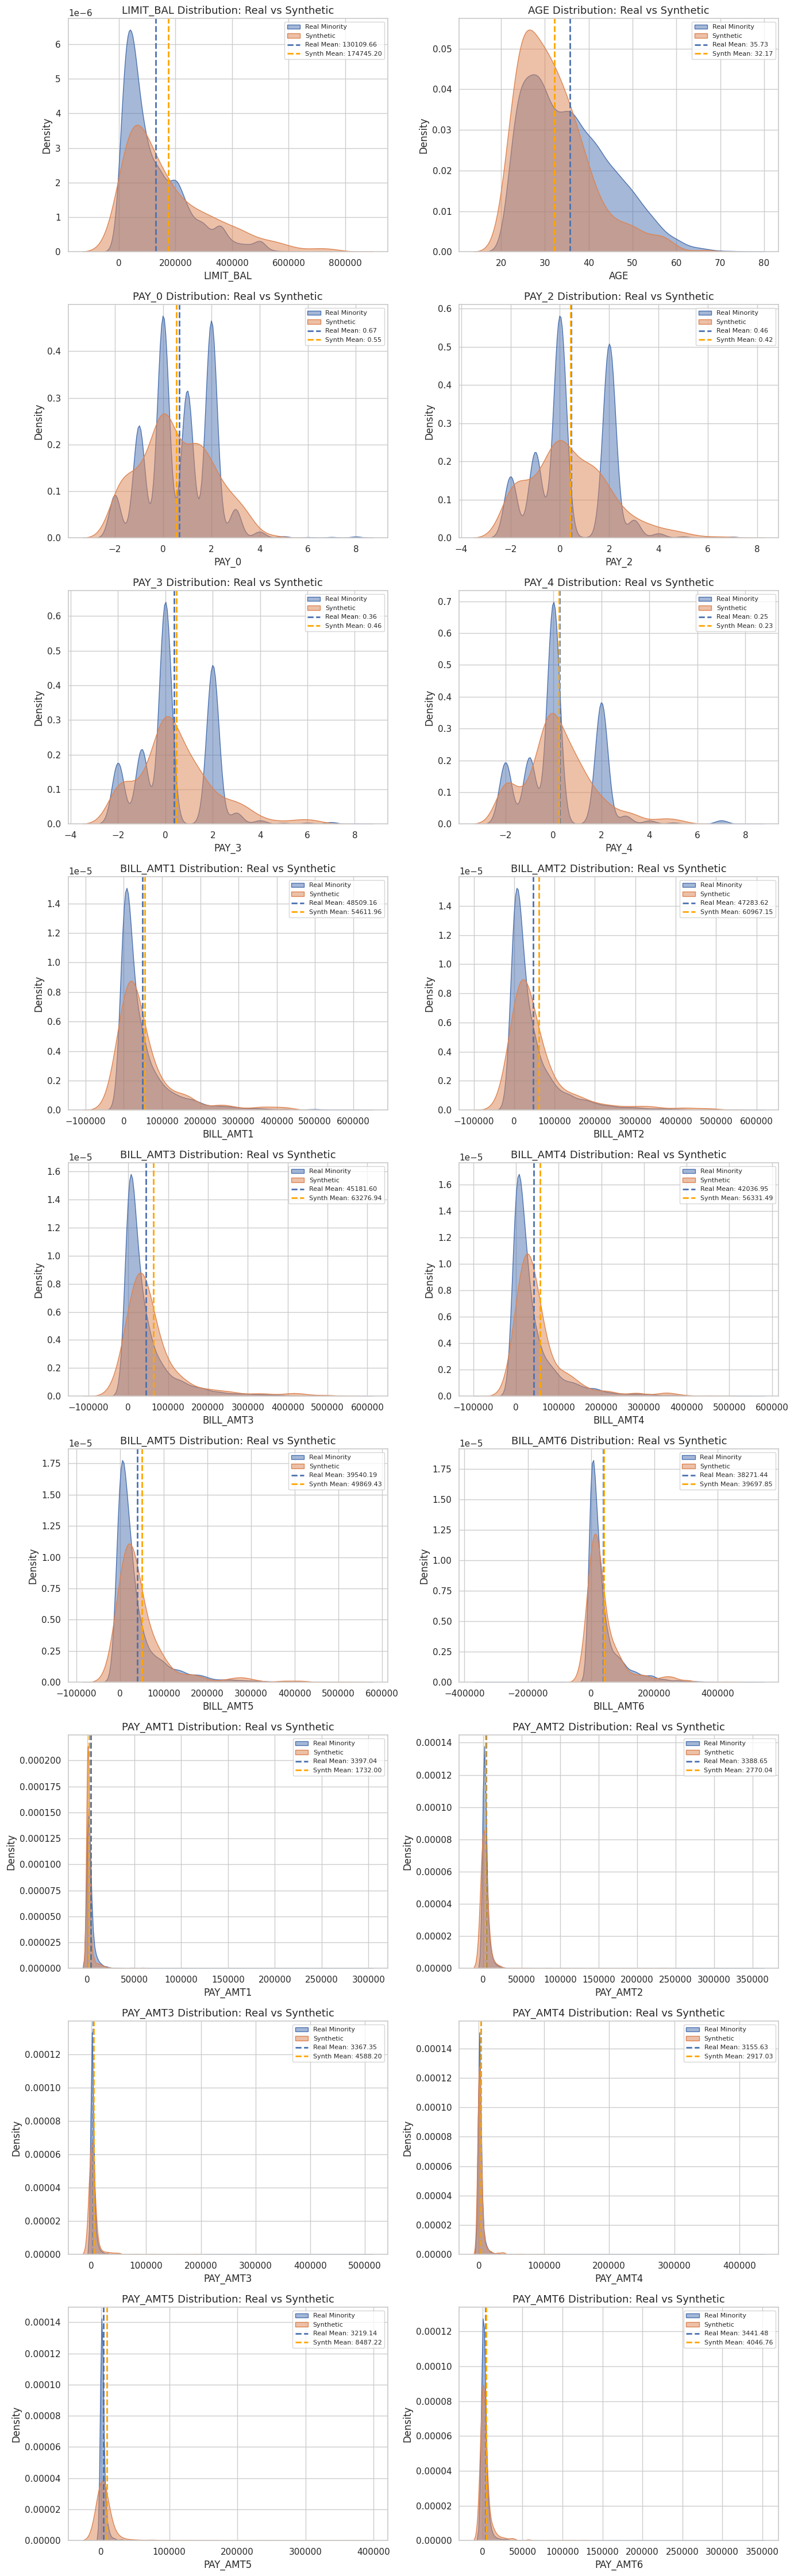

Plotting categorical proportions with value labels...


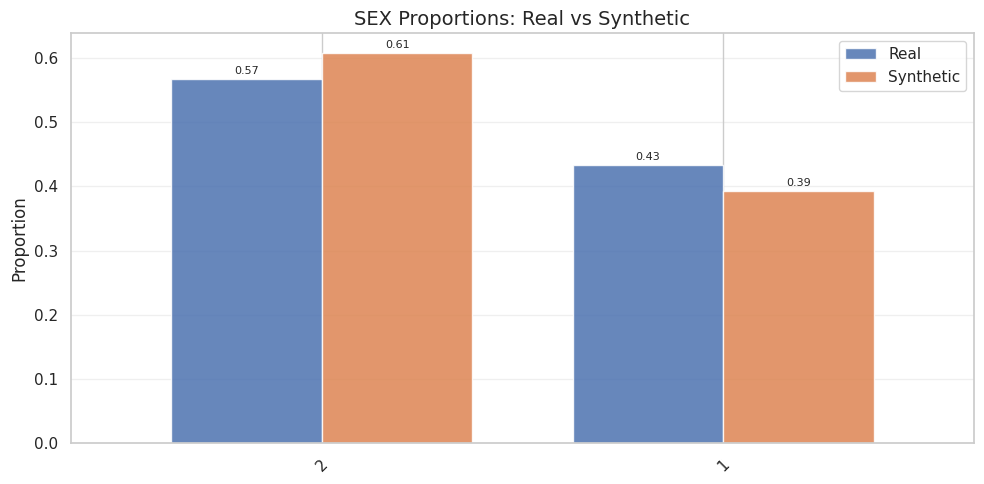

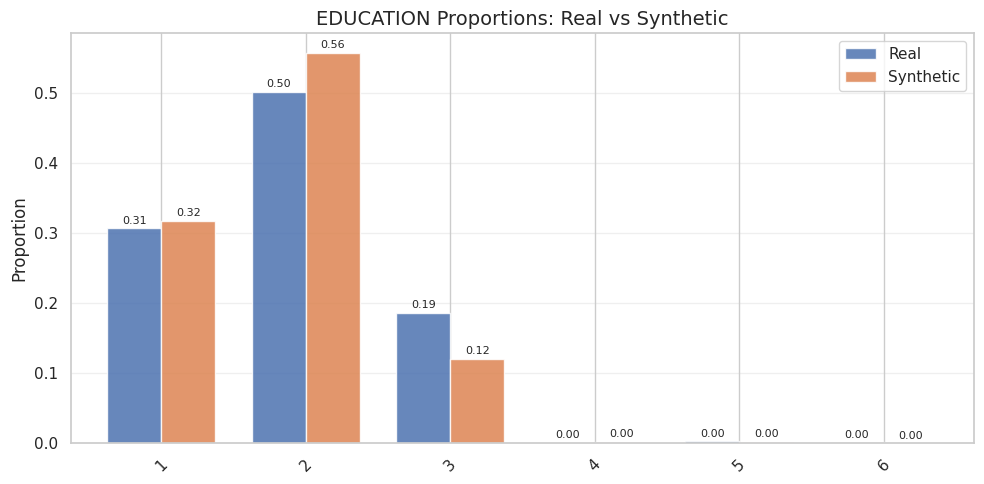

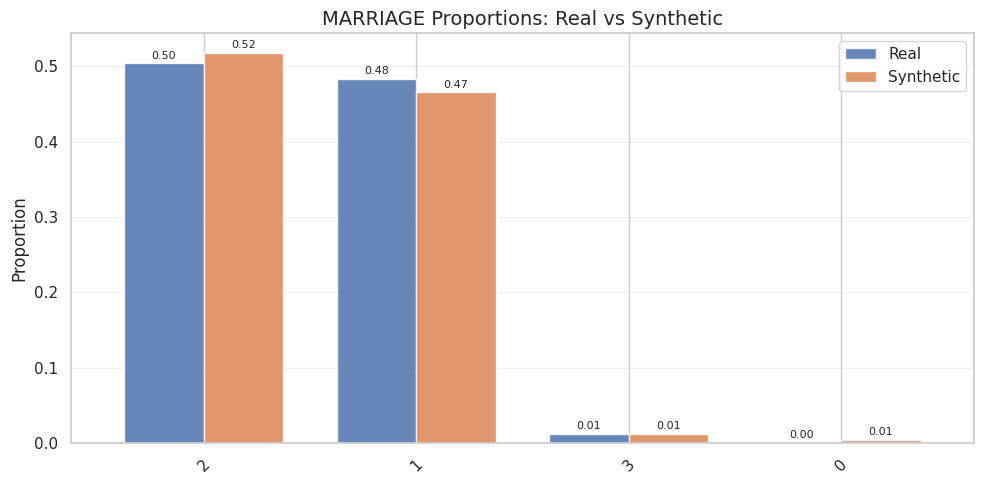

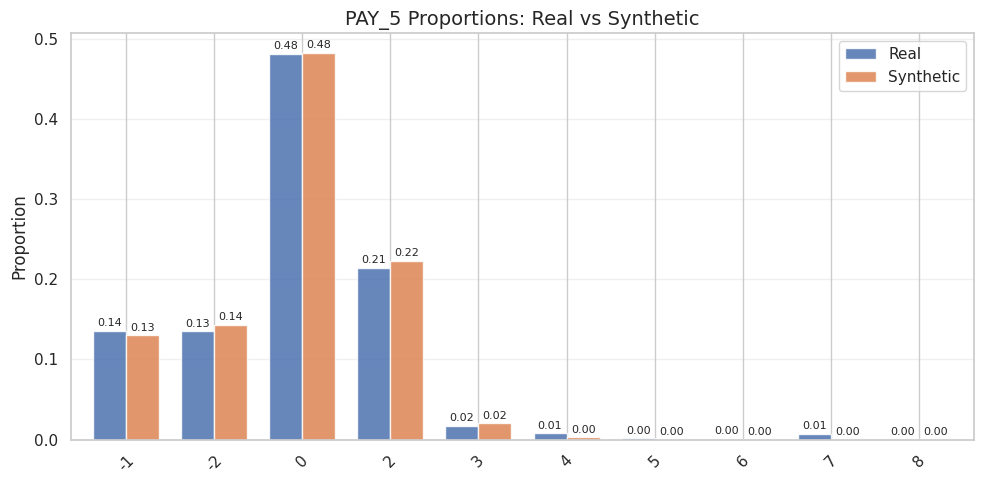

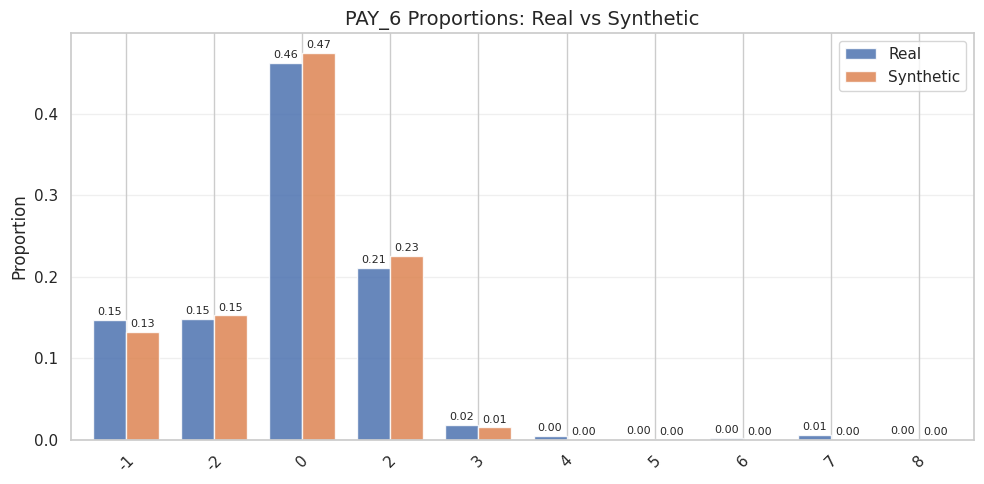

Plotting correlation matrices...


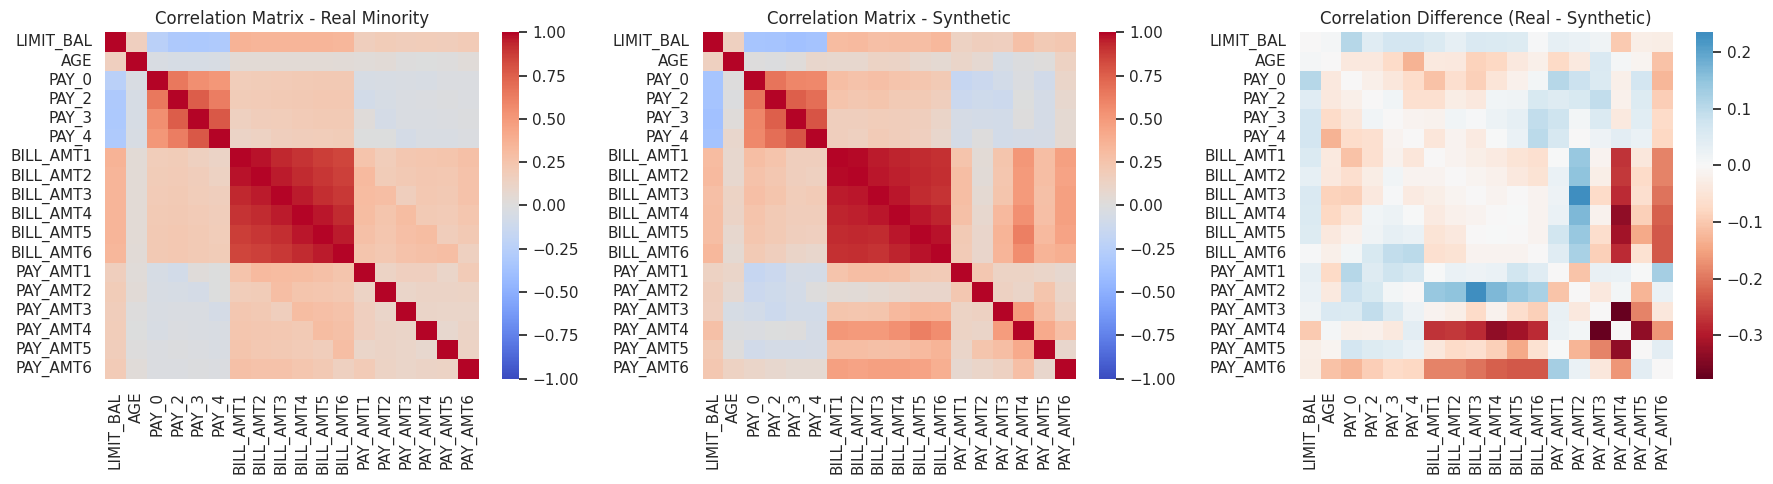

Generating PCA/t‑SNE projections...


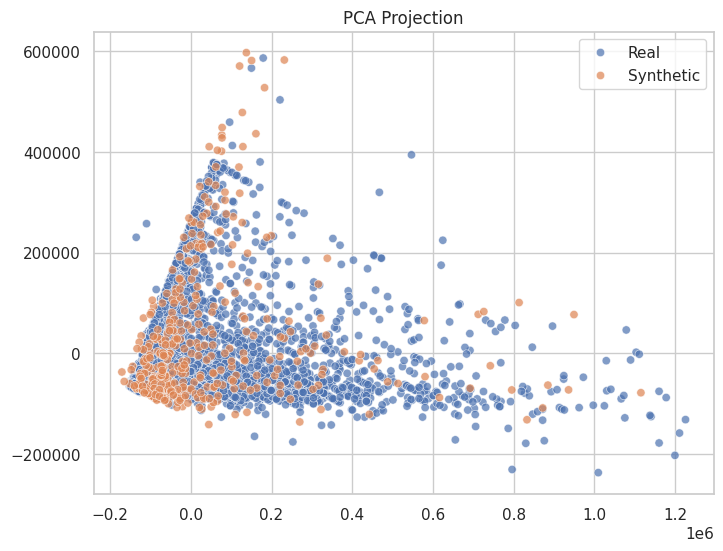

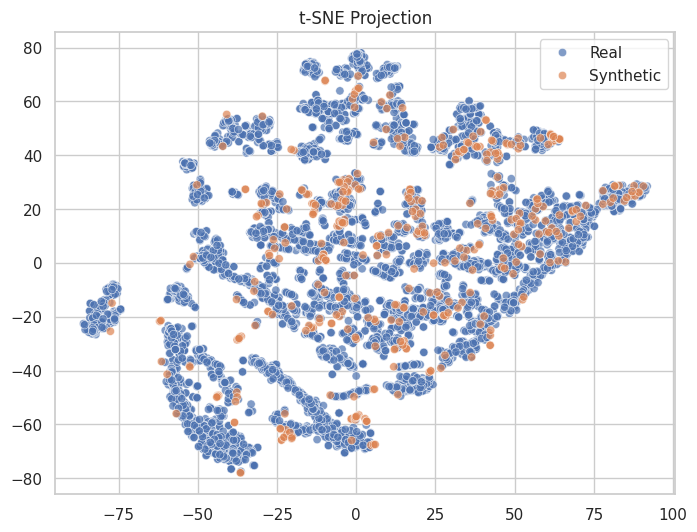


SYNTHETIC DATA QUALITY REPORT

1. NUMERICAL FEATURE STATISTICS:
----------------------------------------
             Feature  Real Mean Synth Mean  Mean Diff %   Real Std  Synth Std Std Diff %
----------------------------------------------------------------------------------------------------
           LIMIT_BAL  130109.66  174745.20         34.3%  115378.54  154694.95       34.1%
                 AGE      35.73      32.17          9.9%       9.69       8.19       15.5%
               PAY_0       0.67       0.55         18.0%       1.38       1.47        6.0%
               PAY_2       0.46       0.42          8.2%       1.50       1.64        9.4%
               PAY_3       0.36       0.46         26.6%       1.50       1.64        9.2%
               PAY_4       0.25       0.23          8.5%       1.51       1.45        3.6%
           BILL_AMT1   48509.16   54611.96         12.6%   73782.07   80648.49        9.3%
           BILL_AMT2   47283.62   60967.15         28.9%   71651.03

In [17]:
# In cwgan_training.ipynb, after Section 7
results = evaluate_generative_quality(
    df_synth_vis=df_synth_vis,
    feature_info=feature_info,
    df_processed=df_processed,
    target_col=target_col,
    minority_label=minority_label,
    save_path='../figures'
)

In [18]:

# %% [markdown]
# ## 8. Balance the Full Dataset (Optional - for Later Modeling)

# %%
# Compute feature ranges from full dataset for clipping
feature_ranges = {col: (df_processed[col].min(), df_processed[col].max()) 
                  for col in feature_info['numerical']}

# Generate enough synthetic samples to balance the entire dataset
majority_count = (df_processed[target_col] != minority_label).sum()
minority_count = (df_processed[target_col] == minority_label).sum()
needed = majority_count - minority_count
print(f"Full dataset: Majority={majority_count}, Minority={minority_count}, Need {needed} synthetic samples.")

if needed > 0:
    df_synth_full = generate_synthetic_samples(
        gan, scaler, needed, feature_info, column_order,
        minority_label=minority_label, target_col=target_col, 
        feature_ranges=feature_ranges
    )
    df_balanced = pd.concat([df_processed, df_synth_full], ignore_index=True)
    print("Balanced shape:", df_balanced.shape)
    print("Class counts after balancing:")
    print(df_balanced[target_col].value_counts())
    
    # Save balanced dataset
    df_balanced.to_csv("../data/processed/default_credit_balanced_cwgan_improved.csv", index=False)
    print("Balanced dataset saved to ../data/processed/default_credit_balanced_cwgan_improved.csv")
else:
    print("Dataset already balanced.")

# %% [markdown]
# ## 9. Next Steps
# - Train XGBoost on the balanced dataset
# - Compare with SMOTE and original imbalanced data using proper train/test split
# - Apply SHAP for explainability

Full dataset: Majority=23364, Minority=6636, Need 16728 synthetic samples.
Balanced shape: (46728, 52)
Class counts after balancing:
Class
1    23364
0    23364
Name: count, dtype: int64
Balanced dataset saved to ../data/processed/default_credit_balanced_cwgan_improved.csv
